In [1]:
import jax
import jax.numpy as jnp
import jax.image
import tensorflow_datasets as tfds
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
import os


2025-06-01 02:06:39.644373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748743599.709647    7249 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748743599.732217    7249 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
def load_and_preprocess_mnist(labels=None, resolution=(8, 8)):
    """Load and preprocess MNIST dataset for specified labels and resolution.
    
    Args:
        labels: List/tuple of integer labels to include, or None for all labels
        resolution: Tuple of (height, width) for output image size
        
    Returns:
        Tuple of (images_array, labels_array) as JAX arrays
    """
    # Build and prepare the MNIST dataset using tensorflow_datasets
    ds_builder = tfds.builder("mnist")
    ds_builder.download_and_prepare()
    
    # Load the training split as supervised (image, label) pairs
    ds = ds_builder.as_dataset(split="train", as_supervised=True)
    
    # Filter for specific labels if provided
    if labels is not None:
        if not isinstance(labels, (list, tuple)):
            labels = [labels]  # Convert single label to list
        ds = ds.filter(lambda _, label: tf.reduce_any([tf.equal(label, l) for l in labels]))
    images_list = []
    labels_list = []
    
    # Iterate over the dataset. Each image is originally 28x28x1
    for image, label in tfds.as_numpy(ds):
        # Normalize image to [0, 1]
        image = image.astype(np.float32) / 255.0
        
        # Convert to a JAX array
        image_jax = jnp.array(image)
        
        # Resize to target resolution. Preserve the channel dimension
        resized = jax.image.resize(image_jax, shape=(*resolution, image_jax.shape[-1]), method='linear')
        
        images_list.append(resized)
        labels_list.append(label)
    
    # Stack the images and labels into arrays
    images_array = jnp.stack(images_list)
    labels_array = jnp.array(labels_list)
    
    return images_array, labels_array

2025-06-01 02:06:41.860830: W external/local_tsl/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


I0000 00:00:1748743605.756419    7249 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10254 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6
2025-06-01 02:06:45.976037: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.8.93. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


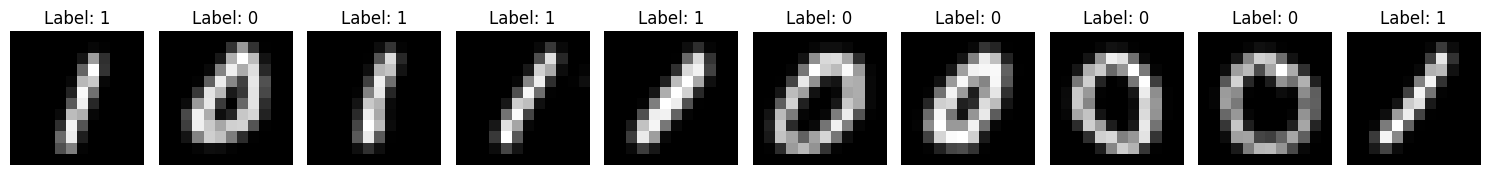

In [4]:
labels = [0,1]
resolution = (12,12)
images, labels_array = load_and_preprocess_mnist(labels=labels, resolution=resolution)

# Plot a few examples
num_examples = 10  # number of examples to display
fig, axes = plt.subplots(1, num_examples, figsize=(15, 2))

for i in range(num_examples):
    # Remove channel dimension if it exists (i.e., converting 8x8x1 to 8x8)
    img = images[i]
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    
    axes[i].imshow(np.array(img), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Label: {labels_array[i]}")

plt.tight_layout()
plt.show()

In [5]:
specifics = f"labels_{labels}_resolution_{resolution}"

# Create the target directory if it doesn't exist.
save_folder = f"../data/MNIST/"
os.makedirs(save_folder, exist_ok=True)

# Save the flattened jnp.array as a .npy file.
save_path = os.path.join(save_folder, f"mnist_{specifics}.npy")
np.save(save_path, np.array(images.reshape(images.shape[0], -1) ))  # Convert to numpy array for saving

print("Saved preprocessed data to:", save_path)

Saved preprocessed data to: ../data/MNIST/mnist_labels_[0, 1]_resolution_(12, 12).npy
